In [146]:
import importlib, sys
# Force reload the module
importlib.reload(sys.modules['Class_definitions'])
importlib.reload(sys.modules['simulate_population'])

<module 'simulate_population' from 'C:\\Users\\dinab\\Desktop\\PhD Projects\\Ensemble methods\\GitHub_App\\medicaljourneys\\simulate_population.py'>

In [147]:
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from lifelines import CoxPHFitter
from lifelines.utils import concordance_index
from simulate_population import sim_population

In [148]:
from Class_definitions import (    prepare_data_simple_timeseries,    train_simple_timeseries,
    get_cindex_simple_timeseries,    SimpleBinaryTimeSeries,
    simplecox, get_cindex_for_event)

In [149]:
#============================================================================
# HYPERPARAMETERS (matching Simple_Cox_with_NN-Copy1)
# ============================================================================
N_POPULATION = 10000

BATCH_SIZE = 512
EPOCHS = 300
HIDDEN_LAYERS_COX = (64, 32)
HIDDEN_LAYERS_MULTIBINARY = (64, 32)
STEP_FORWARD = 2
N_STEPS = 5
N_INTERVALS = int(N_STEPS * STEP_FORWARD)  # time split every 2 years
COVARIATE_COLS = ["age_start", "bmi", "hyp", "smoke", "sex", "eth1", "eth2"]
EVENT_TYPES = ["a", "b", "c", "d", "e"]

# ============================================================================
# PART A: Generate Data
# ============================================================================
print("=" * 80)
print("PART A: Generating Simulation Data")
print("=" * 80)
np.random.seed(42); torch.manual_seed(42) # Set random seed for reproducibility

# Generate population with 5 steps forward, step_forward=2
population_train = sim_population(N= int(N_POPULATION*0.8), step_forward=STEP_FORWARD, randomseed=42)
population_test = sim_population(N= int(N_POPULATION*0.2), step_forward=STEP_FORWARD, randomseed=42+1)
for i in range(N_STEPS): 
    population_train.step()
    population_test.step()

# Get Cox format data (train/test split)
df_cox_train = population_train.to_cox_format()
df_cox_test = population_test.to_cox_format()
print(f"Cox format data shape (train, test): {df_cox_train.shape}, {df_cox_test.shape}")
print(f"Columns: {df_cox.columns.tolist()}\n")

print("=" * 80)
print(f"Prepare the data for the time series; {len(df_cox)} x {N_STEPS+1} samples")
print("=" * 80)

df_train = prepare_data_simple_timeseries( population_train)
df_test = prepare_data_simple_timeseries(population_test)

print(f"Train set: {len(df_train)} rows")
print(f"Test set: {len(df_test)} rows")


PART A: Generating Simulation Data
Cox format data shape (train, test): (8000, 18), (2000, 18)
Columns: ['id', 'age_start', 'bmi', 'hyp', 'smoke', 'sex', 'eth1', 'eth2', 'event_a', 'time_a', 'event_b', 'time_b', 'event_c', 'time_c', 'event_d', 'time_d', 'event_e', 'time_e']

Prepare the data for the time series; 10000 x 6 samples
Train set: 48000 rows
Test set: 12000 rows


# Fit and validate the binary models 

In [150]:
cindex_df_list = list() 

# ===== SIMPLE COX MODEL  =====
print("\n[1/4] Training CoxPH...")
cox_models = {}
cindex_cox = {}
for e in EVENT_TYPES:
    cox_model = simplecox(df_cox_train, covariate_cols=COVARIATE_COLS, event_type=e)
    cox_models[e] = cox_model
    # Get c-index on TEST set (same as neural networks)
    predictions = 1-cox_model.predict_partial_hazard(df_cox_test[COVARIATE_COLS])
    cindex_cox[e] = get_cindex_for_event(predictions, df_cox_test, e)
for e in EVENT_TYPES:
    cindex_df_list.append({'Model': 'CoxPH','Event': e, 'C-Index': cindex_cox[e]})

print(pd.DataFrame(cindex_df_list).pivot_table(index='Event', columns='Model', values='C-Index'))

# ===== LINEAR MODEL (NO HIDDEN LAYERS) =====
print("\n[2/4] Training Simple Binary TimeSeries (Linear)...")
model_linear = train_simple_timeseries(
    df_train,     features=COVARIATE_COLS,    event_types=EVENT_TYPES,    hidden_dims=(),  # NO hidden layers
    lr=0.01,    epochs=300,    batch_size=512)
cindex_linear = get_cindex_simple_timeseries(    model_linear, df_test, COVARIATE_COLS, EVENT_TYPES)
for e in EVENT_TYPES:
    cindex_df_list.append({'Model': 'Binary TimeSeries (Linear)','Event': e, 'C-Index': cindex_linear[e] })
print(pd.DataFrame(cindex_df_list).pivot_table(index='Event', columns='Model', values='C-Index'))

# ===== WITH HIDDEN LAYERS =====
print("\n[3/4] Training Simple Binary TimeSeries (64-32)...")
model_hidden = train_simple_timeseries(
    df_train,    features=COVARIATE_COLS,    event_types=EVENT_TYPES,    hidden_dims=(64, 32),  # Two hidden layers
    lr=0.01, epochs=300,   batch_size=512)
cindex_hidden = get_cindex_simple_timeseries(    model_hidden, df_test, COVARIATE_COLS, EVENT_TYPES)
for e in EVENT_TYPES:
    cindex_df_list.append({'Model': 'Binary TimeSeries (64-32)','Event': e,'C-Index': cindex_hidden[e] })
print(pd.DataFrame(cindex_df_list).pivot_table(index='Event', columns='Model', values='C-Index'))

# ===== WITH MORE LAYERS =====
print("\n[4/4] Training Simple Binary TimeSeries (128-64-32)...")
model_deep = train_simple_timeseries(
    df_train,     features=COVARIATE_COLS,    event_types=EVENT_TYPES,    hidden_dims=(128, 64, 32),  # Three hidden layers
    lr=0.01,    epochs=300,    batch_size=512)
cindex_deep = get_cindex_simple_timeseries(    model_deep, df_test, COVARIATE_COLS, EVENT_TYPES)
for e in EVENT_TYPES:
    cindex_df_list.append({'Model': 'Binary TimeSeries (128-64-32)','Event': e,'C-Index': cindex_deep[e]})
print(pd.DataFrame(cindex_df_list).pivot_table(index='Event', columns='Model', values='C-Index'))

# ===== RESULTS TABLE =====
cindex_df = pd.DataFrame(cindex_df_list)
cindex_pivot = cindex_df.pivot_table(index='Event', columns='Model', values='C-Index')
print("\n" + cindex_pivot.to_string())


[1/4] Training CoxPH...
   Model Event   C-Index
0  CoxPH     a  0.715600
1  CoxPH     b  0.652175
2  CoxPH     c  0.630652
3  CoxPH     d  0.600022
4  CoxPH     e  0.613583

[2/4] Training Simple Binary TimeSeries (Linear)...
Epoch 1/300, Loss: 0.8903
Epoch 51/300, Loss: 0.3925
Epoch 101/300, Loss: 0.3918
Epoch 151/300, Loss: 0.3922
Epoch 201/300, Loss: 0.3926
Epoch 251/300, Loss: 0.3921
Epoch 300/300, Loss: 0.3920
                        Model Event   C-Index
0                       CoxPH     a  0.715600
1                       CoxPH     b  0.652175
2                       CoxPH     c  0.630652
3                       CoxPH     d  0.600022
4                       CoxPH     e  0.613583
5  Binary TimeSeries (Linear)     a  0.700325
6  Binary TimeSeries (Linear)     b  0.646462
7  Binary TimeSeries (Linear)     c  0.629990
8  Binary TimeSeries (Linear)     d  0.584222
9  Binary TimeSeries (Linear)     e  0.602765

[3/4] Training Simple Binary TimeSeries (64-32)...
Epoch 1/300, Loss: 0.

<Axes: title={'center': 'C-Index'}, xlabel='Event'>

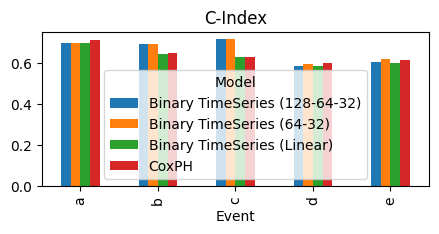

In [185]:
cindex_pivot.plot.bar(figsize = (5,2),title ="C-Index")

In [176]:
coefdf = round(cox_models["a"].summary[['coef']],4)
coefdf2 = pd.DataFrame(model_linear.get_beta(), columns = coefdf.index, index = event_types ).T
coefdf2["coxa"] =  round(cox_models["a"].summary[['coef']],4)
coefdf2["coxb"] =  round(cox_models["b"].summary[['coef']],4)
coefdf2["coxc"] =  round(cox_models["c"].summary[['coef']],4)
coefdf2["coxd"] =  round(cox_models["d"].summary[['coef']],4)
coefdf2["coxe"] =  round(cox_models["e"].summary[['coef']],4)
print("Binary vs Cox betas")
coefdf2.loc[:, ["coxa", "a", "coxb", "b", "coxc", "c","coxd","d", "coxe", "e"]]


Binary vs Cox betas


,coxa,a,coxb,b,coxc,c,coxd,d,coxe,e
covariate,,,,,,,,,,
age_start,0.0270,0.034420,0.0338,0.049137,0.0140,0.013689,0.0249,0.031541,0.0237,0.028898
bmi,0.4946,0.683971,0.0577,0.120182,0.0114,-0.016231,0.0364,0.053970,-0.0162,-0.007334
hyp,0.7196,1.015407,0.6712,0.924739,0.1358,0.171047,0.1068,0.140910,0.0527,0.026393
smoke,0.0199,-0.031178,-0.0612,0.018952,0.9350,1.234051,0.0293,0.049742,-0.0695,-0.043748
sex,-0.0293,-0.028541,-0.0114,-0.008476,0.0127,0.003177,-0.0141,0.008928,0.0928,0.089363
eth1,0.5047,0.670861,0.0873,0.120622,0.0419,0.035635,0.2242,0.233452,0.2090,0.179634
eth2,1.9623,2.844364,0.3171,0.488876,0.0027,0.054900,0.5883,0.604679,0.5004,0.524741


<Axes: title={'center': 'Betas:Binary vs Cox'}>

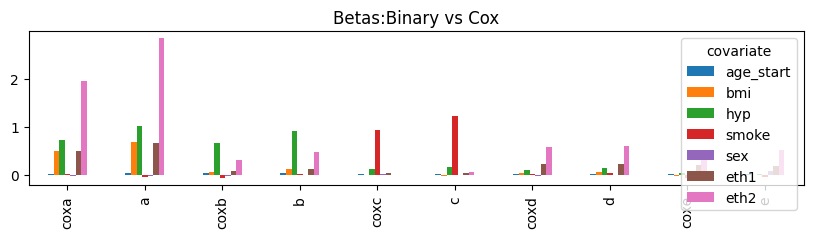

In [184]:
coefdf2.loc[:, 
    ["coxa", "a", "coxb", "b", "coxc", "c","coxd","d", "coxe", "e"]].T.plot.bar(
        figsize = (10,2), title = "Betas:Binary vs Cox")

In [193]:
event_types = ["a","b", "c", "d","e"]
model_deep.get_probability(df_train_long.iloc[1, :],event_types=event_types)

TypeError: SimpleBinaryTimeSeries.get_probability() got an unexpected keyword argument 'event_types'